# Accès aux SONU sous blocage routier, Haïti

Ce carnet lit les tableaux et les figures que `run_all.py` écrit dans `outputs/`. Il ne refait aucun calcul : le code d'analyse reste dans `src/`, où il est testé.

Pour régénérer les sorties : `python run_all.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))

import style
from config import SEUIL_REFERENCE

style.appliquer()
TABLEAUX = RACINE / "outputs" / "tables"
FIGURES = RACINE / "outputs" / "figures"
pd.set_option("display.width", 160)
print("seuil de référence :", SEUIL_REFERENCE, "minutes")

seuil de référence : 60 minutes


## 1. L'incertitude sur l'offre de soins

OpenStreetMap ne renseigne aucun attribut de capacité obstétricale. En Haïti,
l'étiquette `amenity=hospital` traîne encore les traces de la cartographie
d'urgence de 2010 : une partie des points ainsi étiquetés ne sont pas des SONUC.

Faute de pouvoir trancher, l'accessibilité est calculée pour deux définitions de
l'offre, une large et une prudente.

In [2]:
national = pd.read_csv(TABLEAUX / "03_accessibilite_nationale.csv")
national[["offre", "part_30min", "part_60min", "part_120min", "mediane_min"]]

,offre,part_30min,part_60min,part_120min,mediane_min
0,SONUC,0.569430,0.780557,0.940618,19.365956
1,SONUC élargi,0.905293,0.946705,0.957351,5.533228
2,Toute offre de soins,0.907492,0.947893,0.958542,5.232997


D'une définition à l'autre, la couverture à une heure varie de dix-sept points.
La suite retient la définition prudente ; l'écart donne la mesure de ce que
coûte l'incertitude sur les étiquettes.

## 2. L'accès avant toute coupure

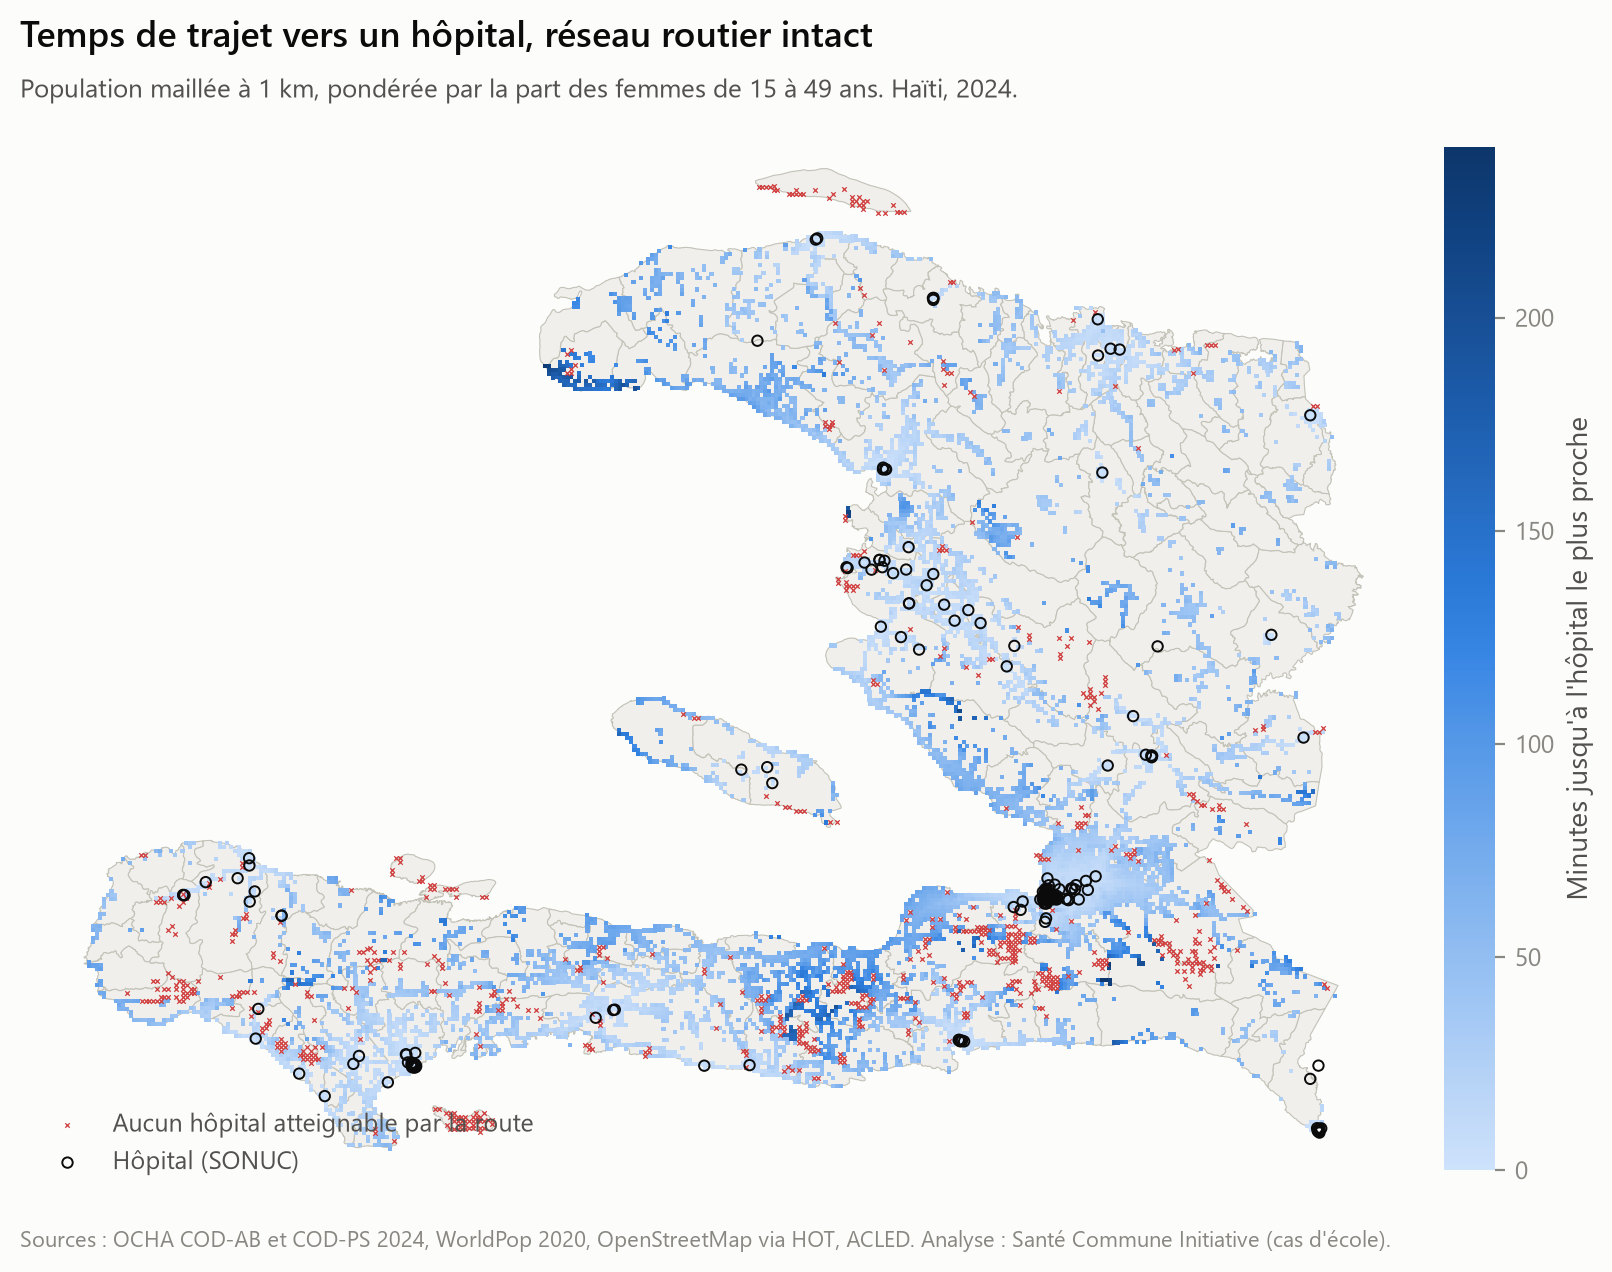

In [3]:
display(Image(filename=str(FIGURES / "fig01_accessibilite_reference.png")))

In [4]:
communes = pd.read_csv(TABLEAUX / "03_accessibilite_par_commune.csv")
colonne = f"part_{SEUIL_REFERENCE}min_sonuc"

pires = communes.nsmallest(12, colonne)[
    ["departement", "commune", "demande", "mediane_sonuc_min", colonne]
]
pires.style.format({"demande": "{:,.0f}", "mediane_sonuc_min": "{:.0f}", colonne: "{:.0%}"})

,departement,commune,demande,mediane_sonuc_min,part_60min_sonuc
0,North,Pilate,"14,392",82,0%
1,South,Ile a Vache,"4,263",nan,0%
2,Grande'Anse,Les Irois,"5,827",80,0%
3,North-West,Bombardopolis,"9,236",155,0%
4,North-West,Baie de Henne,"7,080",104,0%
5,North-West,Mole Saint Nicolas,"9,144",105,0%
6,North-West,La Tortue,"10,364",nan,0%
7,North-East,Vallieres,"7,037",78,0%
8,Nippes,Plaisance du Sud,"7,389",72,0%
9,Centre,Maissade,"19,482",82,0%


Trois communes n'ont pas de médiane : aucune de leurs cellules n'atteint un
SONUC par la route. L'Île-à-Vache et La Tortue sont des îles, avec leur propre
sous-réseau routier et aucune structure qualifiée dessus. Grand-Boucan, dans les
Nippes, est sur la terre ferme, mais son morceau de réseau ne rejoint aucun
SONUC ; sous la définition élargie de l'offre, 76 % de sa demande revient sous
la barre des 60 minutes.

## 3. Charge et criticité des tronçons

Les tronçons sont d'abord présélectionnés sur la demande qui les emprunte, puis
classés sur le dommage : on retire l'arête du graphe et on recalcule
l'accessibilité du pays sans elle.

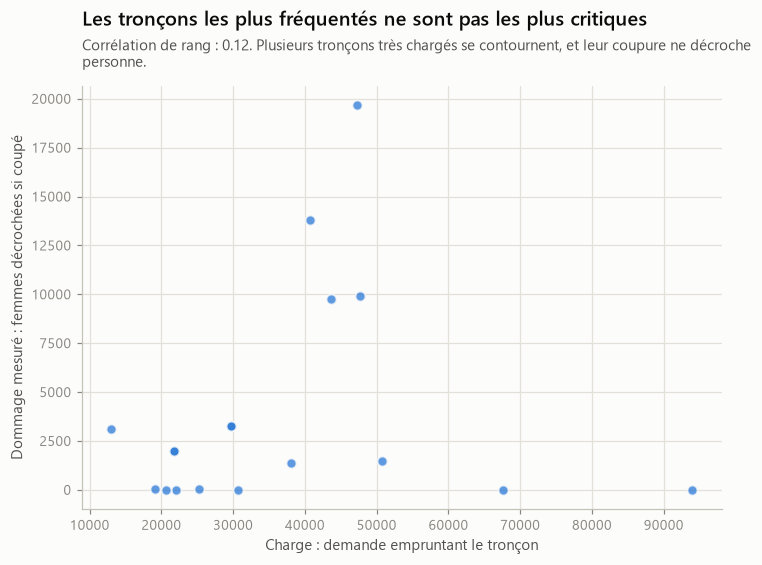

In [5]:
criticite = pd.read_csv(TABLEAUX / "04_criticite_troncons.csv")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.grid(zorder=0)
ax.scatter(
    criticite["charge"], criticite["demande_decrochee"],
    s=42, color=style.SERIE_1, alpha=0.75, zorder=3,
    edgecolor=style.SURFACE, linewidths=1.2,
)
ax.set_xlabel("Charge : demande empruntant le tronçon")
ax.set_ylabel("Dommage mesuré : femmes décrochées si coupé")
style.titrer(
    ax,
    "Les tronçons les plus fréquentés ne sont pas les plus critiques",
    f"Corrélation de rang : {criticite['charge'].corr(criticite['demande_decrochee'], method='spearman'):.2f}. "
    "Plusieurs tronçons très chargés se contournent, et leur coupure ne décroche personne.",
)
plt.show()

In [6]:
criticite.head(8)[
    ["arete", "commune", "classe", "charge", "demande_decrochee", "minutes_perdues_ponderees"]
].style.format({
    "charge": "{:,.0f}", "demande_decrochee": "{:,.0f}",
    "minutes_perdues_ponderees": "{:,.0f}",
})

,arete,commune,classe,charge,demande_decrochee,minutes_perdues_ponderees
0,279959,HT0531,primary,"47,243","19,689","1,210,501"
1,282921,HT0531,primary,"40,709","13,827","1,024,704"
2,280639,HT0531,primary,"47,636","9,896","553,395"
3,281592,HT0531,primary,"43,632","9,766","411,402"
4,244336,HT0621,primary,"29,660","3,293","340,878"
5,244489,HT0621,primary,"29,625","3,284","339,931"
6,244600,HT0621,primary,"21,771","1,974","198,503"
7,1335505,HT0621,primary,"21,733","1,974","197,599"


`HT0531` est Saint-Marc, `HT0621` Mirebalais. Presque tout le dommage se
concentre sur quatre tronçons de la RN1 et quatre de la RN3.

## 4. Les scénarios

In [7]:
scenarios = pd.read_csv(TABLEAUX / "04_synthese_scenarios.csv")
scenarios[
    ["scenario", "part_30min", "part_60min", "part_120min", "mediane_min",
     "part_non_atteignable", "demande_decrochee"]
].style.format({
    "part_30min": "{:.1%}", "part_60min": "{:.1%}", "part_120min": "{:.1%}",
    "mediane_min": "{:.0f}", "part_non_atteignable": "{:.1%}",
    "demande_decrochee": "{:,.0f}",
})

,scenario,part_30min,part_60min,part_120min,mediane_min,part_non_atteignable,demande_decrochee
0,"Référence, réseau et offre intacts",56.9%,78.1%,94.1%,19,4.8%,0
1,A. 10 points de contrôle,56.6%,77.3%,94.0%,19,4.9%,"23,131"
2,B. Encerclement de la ZMPP,55.8%,76.3%,92.8%,20,5.9%,"57,056"
3,C. A et B cumulés,55.4%,75.6%,92.7%,20,5.9%,"80,186"
4,D. Fermeture des hôpitaux de la ZMPP,45.4%,77.5%,94.0%,32,4.8%,"18,235"
5,E. C et D cumulés,41.3%,74.4%,92.3%,33,5.9%,"118,721"


Le scénario D ferme les 77 hôpitaux de l'aire métropolitaine. La couverture à 60
minutes bouge à peine, mais celle à 30 minutes passe de 57 % à 45 % et le temps
médian de 19 à 32 minutes. Les femmes sont éloignées, pas coupées.

Le scénario B, l'encerclement, fait passer de 4,8 % à 5,9 % la part de la
demande qui n'atteint plus aucun hôpital par la route. Là, il y a bien coupure.

Lus au seul seuil de 60 minutes, les deux scénarios se seraient ressemblés.

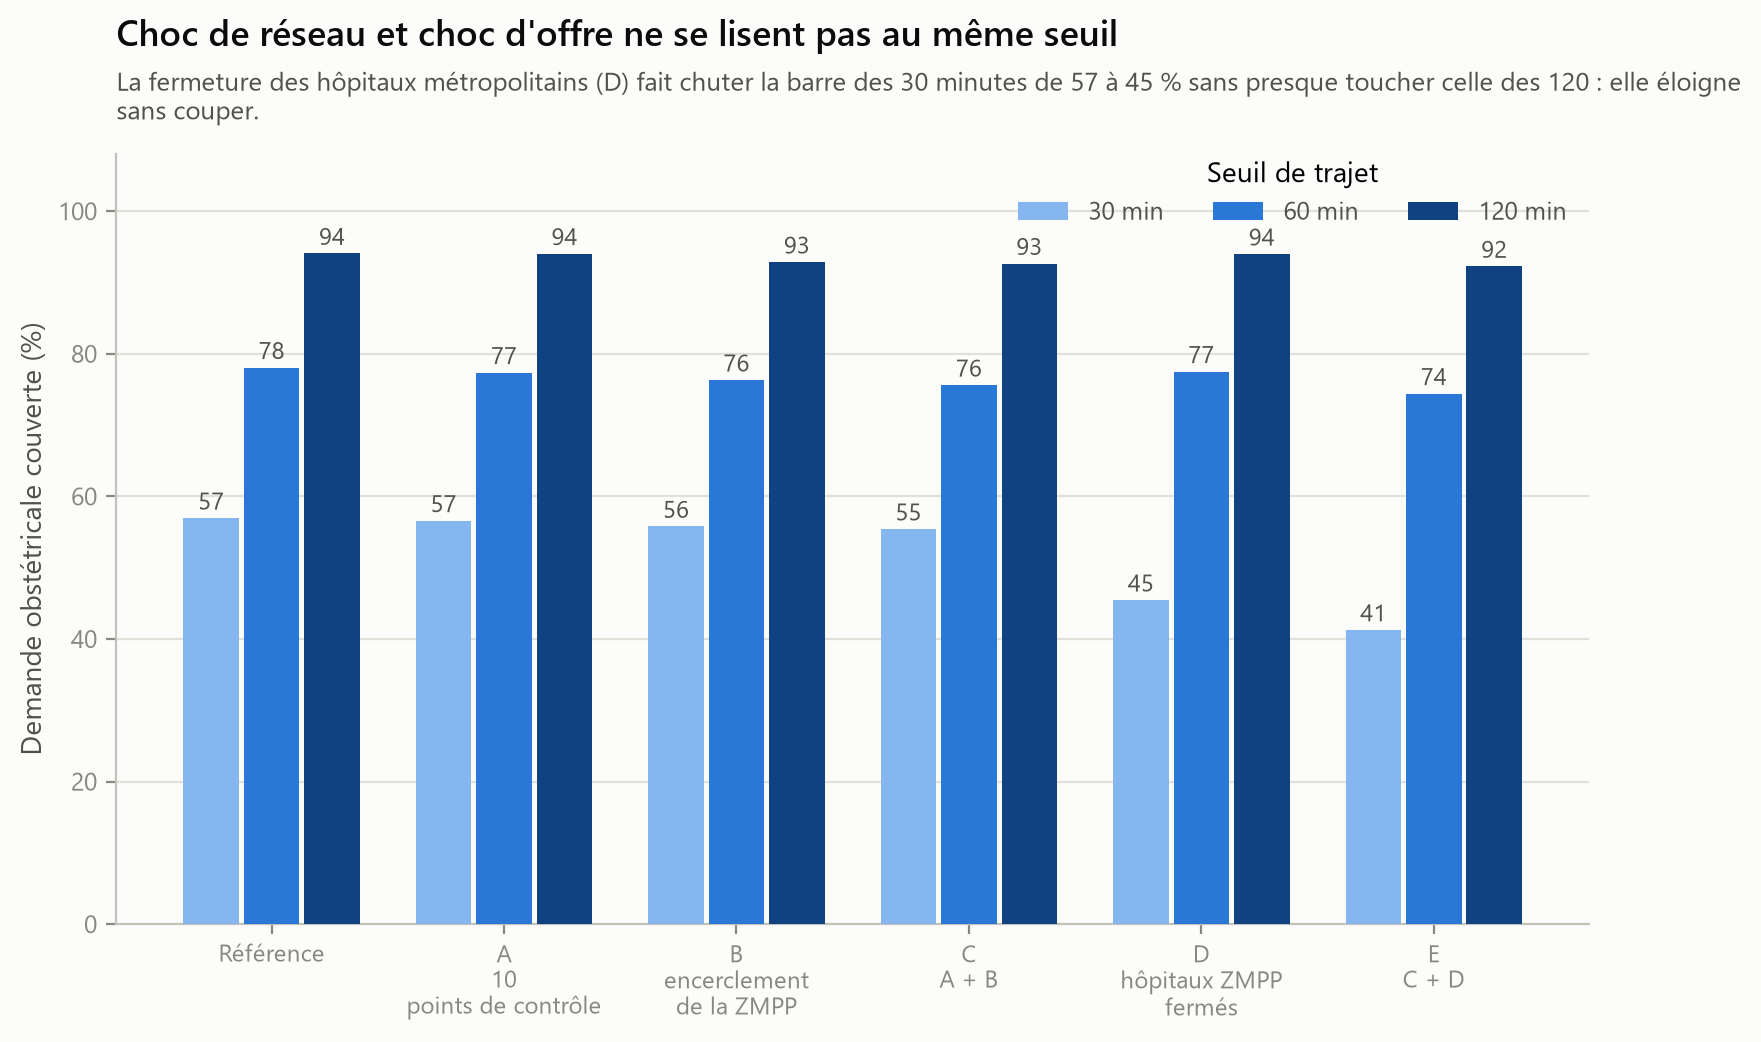

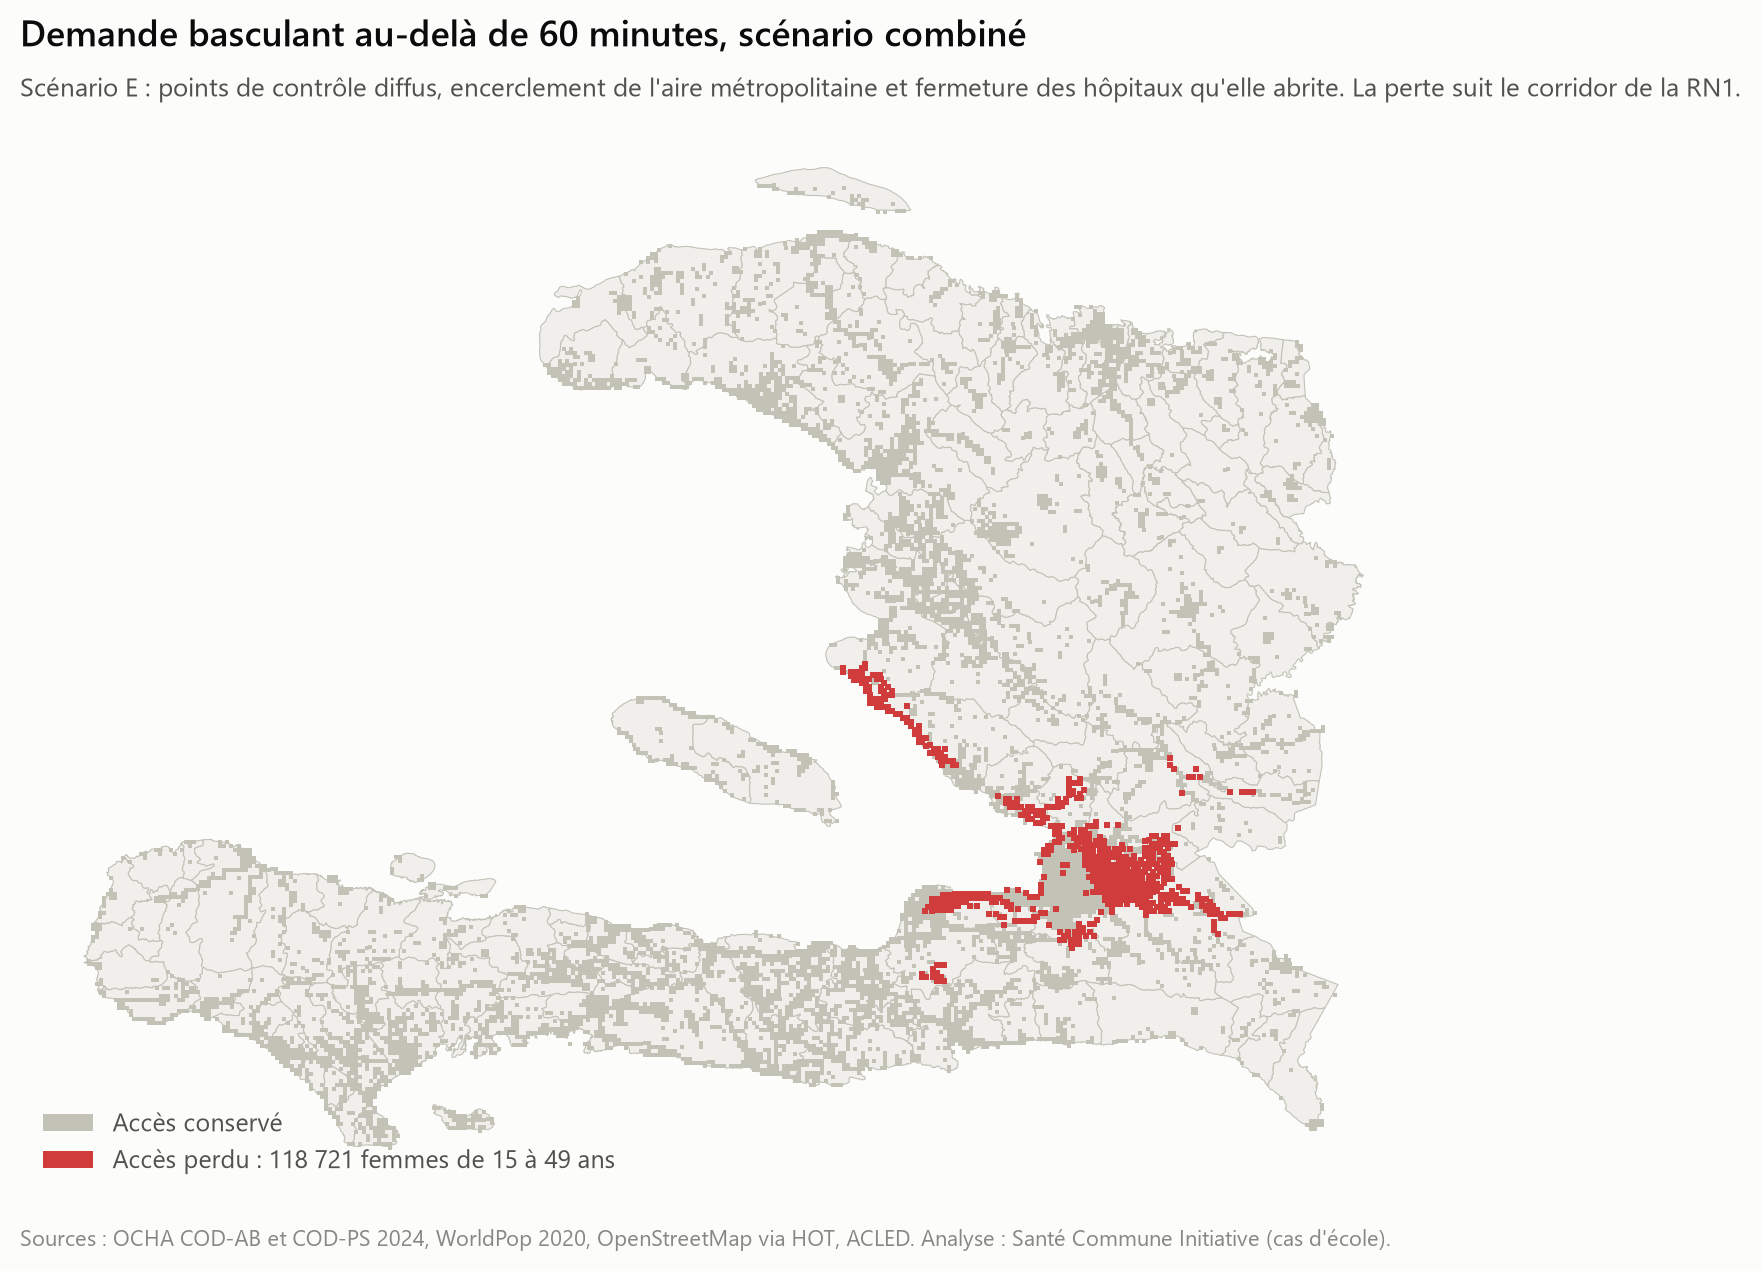

In [8]:
display(Image(filename=str(FIGURES / "fig06_synthese_scenarios.png")))
display(Image(filename=str(FIGURES / "fig04_impact_scenario_cumule.png")))

## 5. Regarder une commune en particulier

La fonction ci-dessous rassemble accessibilité et impact pour toutes les
communes dont le nom contient la chaîne cherchée.

In [9]:
def profil(nom_partiel: str) -> pd.DataFrame:
    """Profil d'accessibilité et d'impact des communes dont le nom correspond."""
    acces = pd.read_csv(TABLEAUX / "03_accessibilite_par_commune.csv")
    impact = pd.read_csv(TABLEAUX / "04_impact_par_commune.csv")
    fusion = acces.merge(
        impact[["pcode", "demande_decrochee", "part_decrochee", "minutes_perdues_medianes"]],
        on="pcode", how="left",
    )
    masque = fusion["commune"].str.contains(nom_partiel, case=False, na=False)
    return fusion.loc[masque, [
        "departement", "commune", "demande", "mediane_sonuc_min",
        f"part_{SEUIL_REFERENCE}min_sonuc", "demande_decrochee", "part_decrochee",
    ]]


profil("Goave")

,departement,commune,demande,mediane_sonuc_min,part_60min_sonuc,demande_decrochee,part_decrochee
12,West,Grand-Goave,36927.0,93.711121,0.001116,0.0,0.0
13,West,Petit-Goave,46232.0,75.535218,0.007518,0.0,0.0


## Une limite à garder en tête

Les points de contrôle sont simulés. Le jeu ACLED diffusé sur HDX est agrégé au
mois et à la commune, sans coordonnée d'incident : la position des barrages sort
d'une règle de placement, explicite et reproductible, mais qui reste une
hypothèse. Ces cartes montrent des barrages plausibles, jamais les barrages
réels.